In [1]:
import pandas as pd
import numpy as np

df = pd.read_pickle('data/df.pkl')
df = df.drop('geometry', axis = 1)
# df = df.drop('date', axis = 1)
columns = df.columns

df = df.sample(frac = 1)

# df_val = df[df['year'] == 2025].copy()
# df = df.drop(df_val.index)
# # Define features and target
columns = [(col) for col in df.columns]
non_features = [
    (col) for col in df.columns if 'ndvi' in str(col) or 'late' in str(col)
] + [
    'year', 'month','plot_id', 'geometry', 'key_0', 'area_m2'
] + [
    i for i in range(0, 367, 1)
]
features = [(col) for col in df.columns if col not in non_features]
target = np.sqrt((df['ndvi_integral']))
X = df[features]

# --- Plot-wise train / val / test split ---
plots = df['plot_id'].unique()
np.random.shuffle(plots)

n_train = int(len(plots)*0.7)
n_val   = int(len(plots)*0.15)

train_plots = plots[:n_train]
val_plots   = plots[n_train:n_train+n_val]
test_plots  = plots[n_train+n_val:]

train_mask = df['plot_id'].isin(train_plots)
val_mask   = df['plot_id'].isin(val_plots)
test_mask  = df['plot_id'].isin(test_plots)

X_train, y_train = X[train_mask], target[train_mask]
X_val, y_val     = X[val_mask], target[val_mask]
X_test, y_test   = X[test_mask], target[test_mask]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (271, 369), Val: (56, 369), Test: (64, 369)


In [2]:
# Install XGBoost if not installed
# !pip install xgboost

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)


In [4]:
estimators = [
    ('rf', rf),
    ('xgb', xgb),
    ('mlp', mlp)
]

stacked_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),  # meta-learner
    n_jobs=-1,
    passthrough=False  # predictions of base learners are fed to meta-learner
)


In [5]:
stacked_model.fit(X_train, y_train)


StackingRegressor(estimators=[('rf',
                               RandomForestRegressor(max_depth=10,
                                                     max_features='sqrt',
                                                     min_samples_leaf=5,
                                                     n_estimators=500,
                                                     n_jobs=-1,
                                                     random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.7,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                          

In [6]:
# Predictions
y_train_pred = (stacked_model.predict(X_train))
y_val_pred   = (stacked_model.predict(X_val))
y_test_pred  = (stacked_model.predict(X_test))

# Metrics
def evaluate(y_true, y_pred, name):
    print(f"{name} R²: {r2_score(y_true, y_pred):.3f}")
    print(f"{name} RMSE: {mean_squared_error(y_true, y_pred, squared=False):.3f}\n")

evaluate((y_train), y_train_pred, "Train")
evaluate((y_val), y_val_pred, "Validation")
evaluate((y_test), y_test_pred, "Test")


Train R²: 1.000
Train RMSE: 0.012

Validation R²: 0.517
Validation RMSE: 0.496

Test R²: 0.762
Test RMSE: 0.338



In [7]:
import matplotlib.pyplot as plt

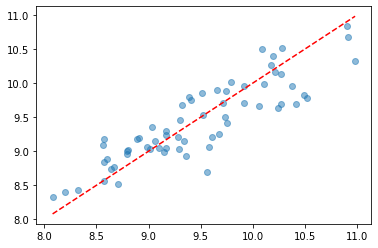

In [10]:
plt.scatter((y_test), y_test_pred, alpha = 0.5)
plt.plot([(y_test).min(), (y_test).max()], [(y_test).min(), (y_test).max()], '--r')

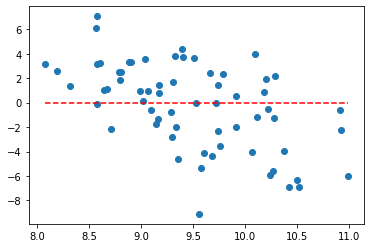

In [9]:
plt.scatter((y_test), (y_test_pred - (y_test)) / (y_test) * 100)
plt.plot([(y_test).min(), (y_test).max()], [0,0], '--r')